Paired with the Notion page, EDA on COMPAS-2

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [72]:
df = pd.read_csv("mol_datasets/compas-2x.csv")
df = df.drop(columns=["Unnamed: 0"])
print(len(df))
df.head()

1573176


,name,charge,formula,inchi,smiles,rings,aromatic_rings,atoms,heteroatoms,heterocycles,...,aip,aea,dipole,homo_corr,lumo_corr,gap_corr,energy_corr,aip_corr,aea_corr,nfod
0,C2M000000,1,C32H18N2,InChI=1S/C32H18N2/c1-2-8-20-19(7-1)13-14-25-21...,[H]c1nc2c([H])c3c4c([H])c([H])c([H])c([H])c4c4...,8,8,52,2,1,...,NaN,NaN,"[-0.34002371, -1.84246813, -0.32428194]",NaN,NaN,NaN,NaN,NaN,NaN,0.8682
1,C2M000000,0,C32H18N2,InChI=1S/C32H18N2/c1-2-8-20-19(7-1)13-14-25-21...,[H]c1nc2c([H])c3c4c([H])c([H])c([H])c([H])c4c4...,8,8,52,2,1,...,12.433219,-7.27947,"[0.17709167, 0.16517448, 0.33076977]",-6.792579,-1.327613,5.45307,-1338.154812,6.937271,-1.169635,0.8682
2,C2M000000,-1,C32H18N2,InChI=1S/C32H18N2/c1-2-8-20-19(7-1)13-14-25-21...,[H]c1nc2c([H])c3c4c([H])c([H])c([H])c([H])c4c4...,8,8,52,2,1,...,NaN,NaN,"[0.97469057, 2.39438874, 1.89003097]",NaN,NaN,NaN,NaN,NaN,NaN,0.8682
3,C2M000001,1,C37H19N,InChI=1S/C37H19N/c1-2-7-21-15-27-22(14-20(21)6...,[H]c1nc2c(c([H])c1[H])c1c([H])c3c(c([H])c21)c1...,10,10,57,1,1,...,NaN,NaN,"[-0.73428558, 0.46502088, 0.14686943]",NaN,NaN,NaN,NaN,NaN,NaN,1.0676
4,C2M000001,-1,C37H19N,InChI=1S/C37H19N/c1-2-7-21-15-27-22(14-20(21)6...,[H]c1nc2c(c([H])c1[H])c1c([H])c3c(c([H])c21)c1...,10,10,57,1,1,...,NaN,NaN,"[-0.56759877, -1.00757353, -0.81254878]",NaN,NaN,NaN,NaN,NaN,NaN,1.0676


In [ ]:
def clean_number(val):
    """Convert floats that are effectively integers into int."""
    if isinstance(val, (int, np.integer)):
        return int(val)
    if isinstance(val, (float, np.floating)):
        if np.isclose(val, int(val), atol=1e-8):
            return int(val)
    return val

def feature_summary(df, sample_size=1):
    summary = []
    for col in df.columns:
        dtype = df[col].dtype
        n_unique = df[col].nunique(dropna=True)
        samples = df[col].dropna().unique()[:sample_size]
        samples = list(samples) + [None]*(sample_size - len(samples))
        
        if pd.api.types.is_numeric_dtype(df[col]):
            col_min = clean_number(df[col].min(skipna=True))
            col_max = clean_number(df[col].max(skipna=True))
        else:
            col_min = None
            col_max = None
        
        summary.append({
            "Feature": col,
            "Data Type": str(dtype),
            "Unique Values": n_unique,
            "Sample 1": samples[0],
            "Min": col_min,
            "Max": col_max
        })
    return pd.DataFrame(summary)

summary_df = feature_summary(df)

# Split into two DataFrames
first_features = [
    'name','charge','formula','inchi','smiles',
    'rings','aromatic_rings','atoms','heteroatoms','heterocycles','branch',
    'cyclobutadiene','pyrrole','borole','furan','thiophene','dhdiborinine',
    '14diborinine','pyrazine','pyridine','borinine','benzene',
    'h','c','b','s','o','n'
]

df_first = summary_df[summary_df['Feature'].isin(first_features)].reset_index(drop=True)
df_other = summary_df[~summary_df['Feature'].isin(first_features)].reset_index(drop=True)

df_first

,Feature,Data Type,Unique Values,Sample 1,Min,Max
0,name,object,524392,C2M000000,NaN,NaN
1,charge,int64,3,1,-1.0,1.0
2,formula,object,22735,C32H18N2,NaN,NaN
3,inchi,object,524390,InChI=1S/C32H18N2/c1-2-8-20-19(7-1)13-14-25-21...,NaN,NaN
4,smiles,object,524390,[H]c1nc2c([H])c3c4c([H])c([H])c([H])c([H])c4c4...,NaN,NaN
5,rings,int64,9,8,2.0,10.0
6,aromatic_rings,int64,11,8,0.0,10.0
7,atoms,int64,57,52,10.0,66.0
8,heteroatoms,int64,18,2,0.0,17.0
9,heterocycles,int64,11,1,0.0,10.0


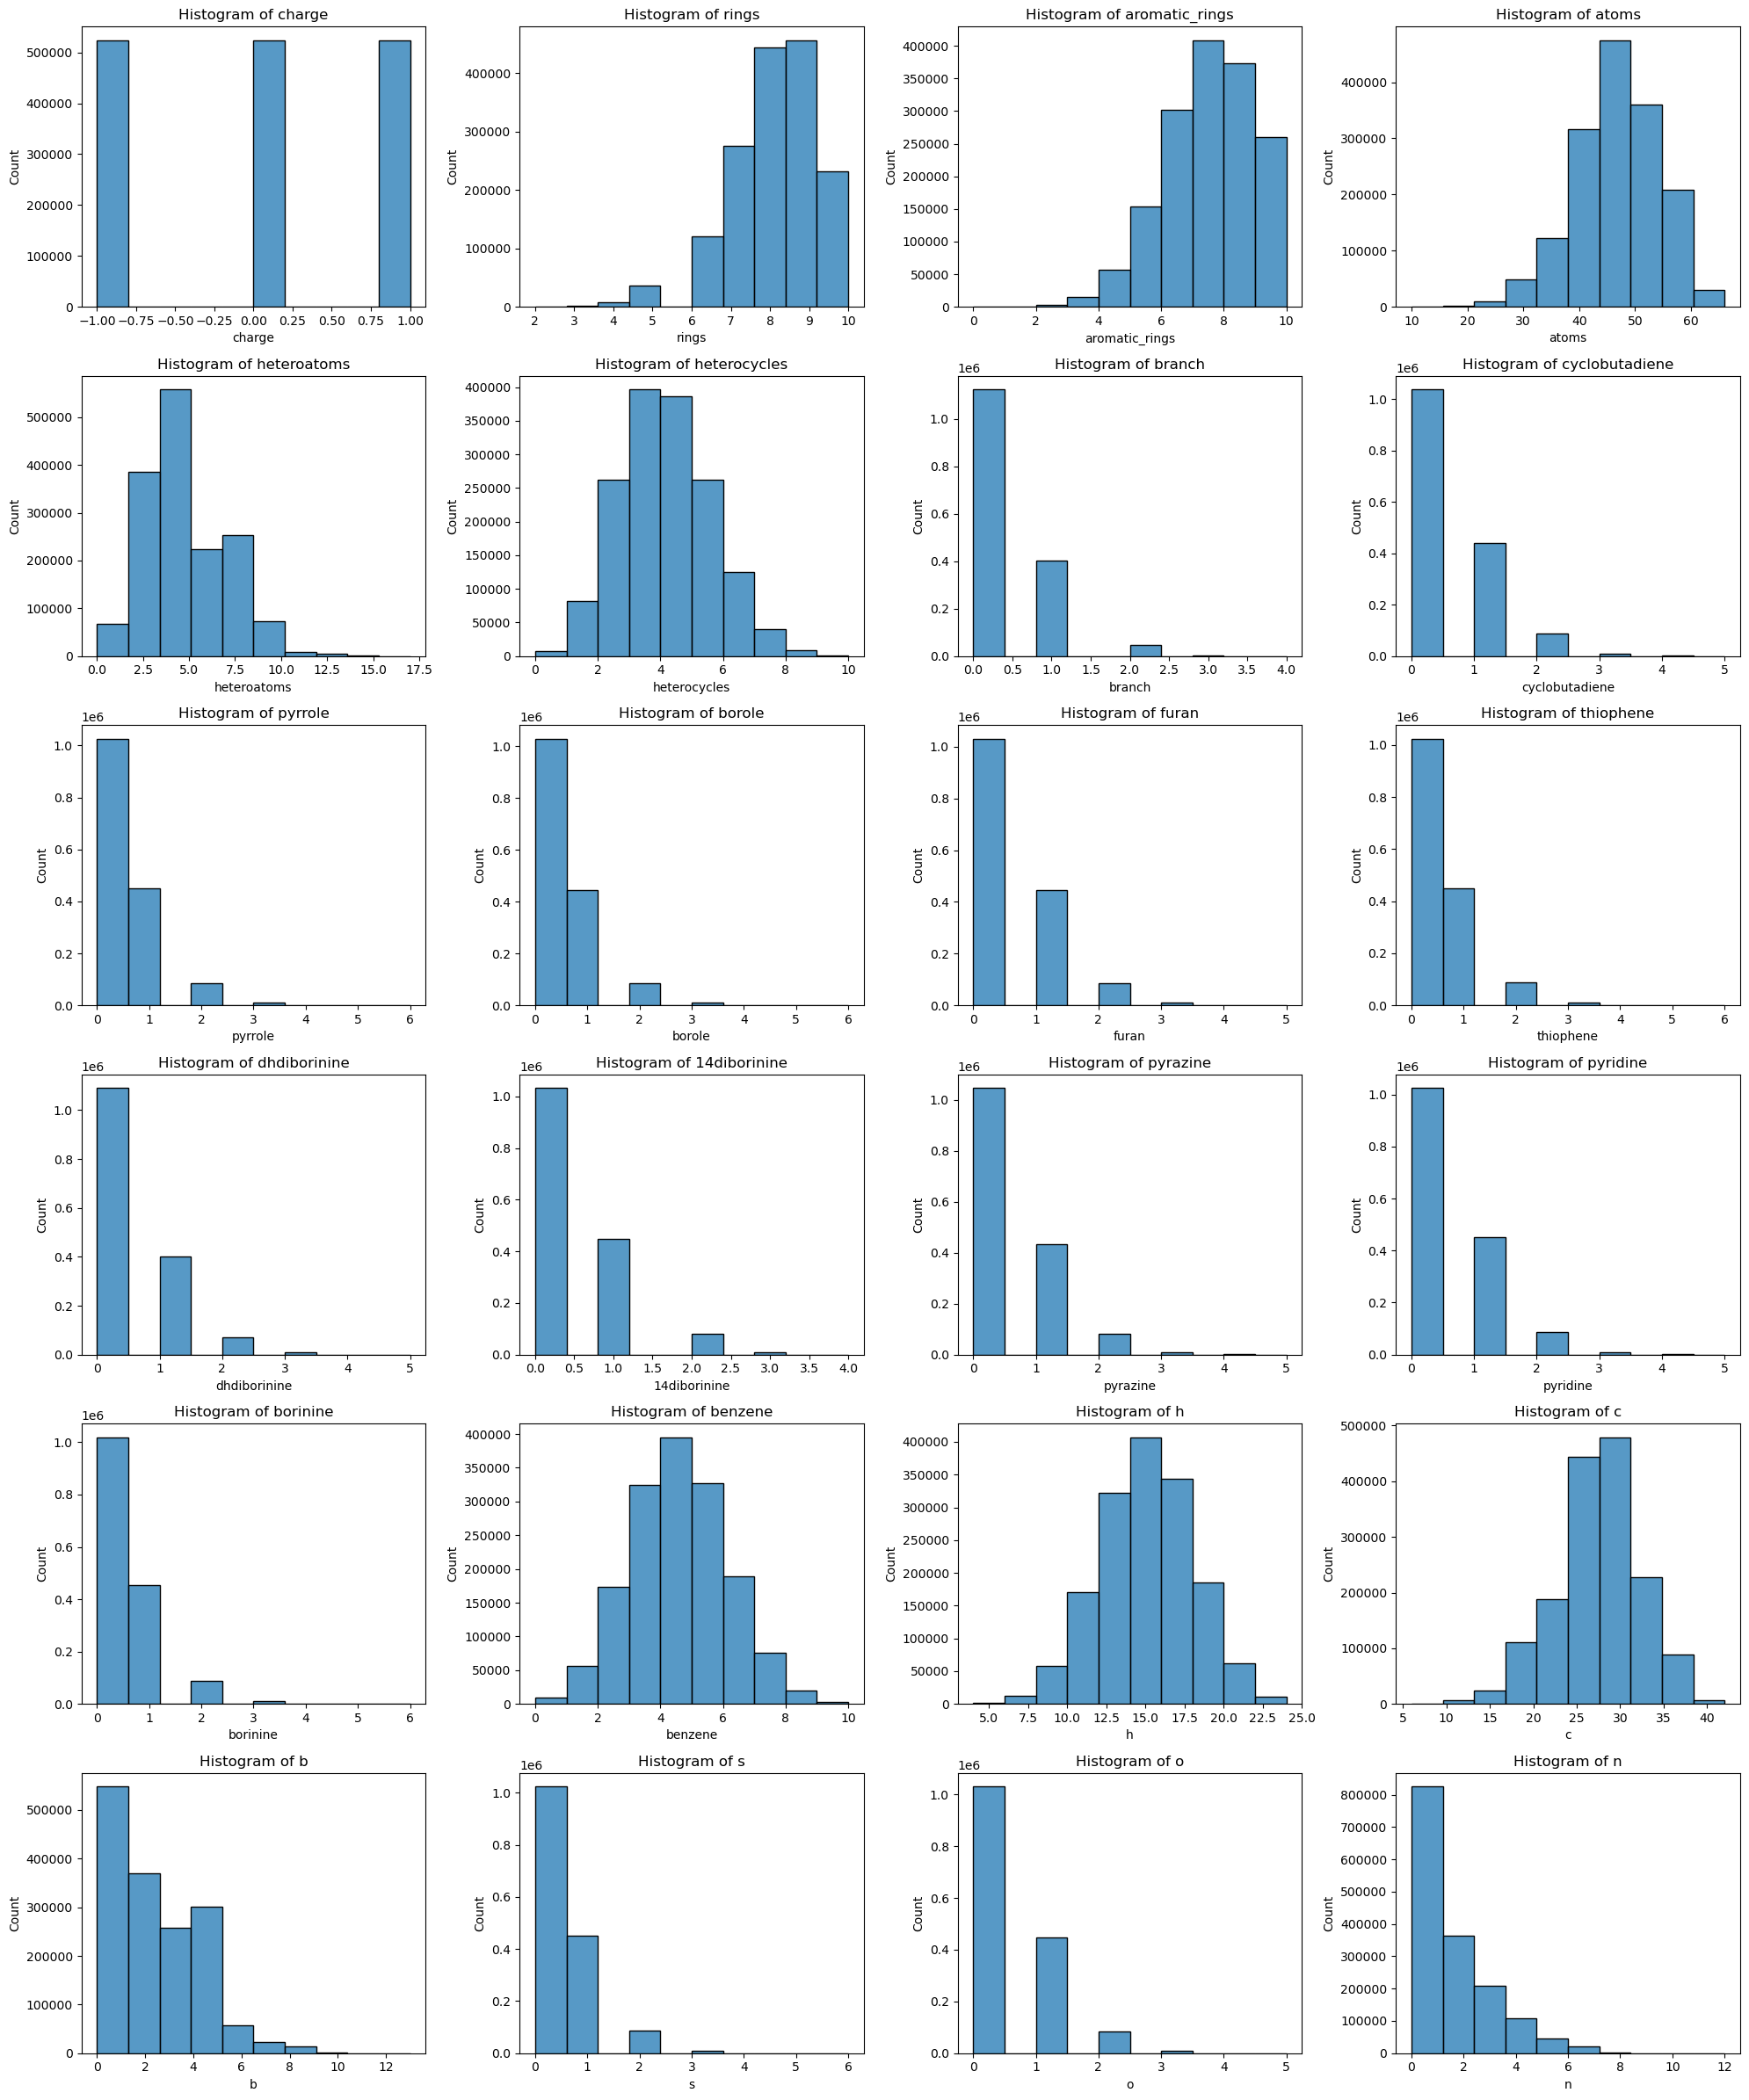

In [37]:
numeric_cols = df.select_dtypes(include=['int64']).columns

# Define subplot grid
n_cols = 4   # number of plots per row
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=10, kde=False, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [31]:
df_other

,Feature,Data Type,Unique Values,Sample 1,Min,Max
0,homo,float64,1570724,-14.00525,-1.712336e+01,-1.537395
1,lumo,float64,1570910,-12.244141,-1.527671e+01,0.013451
2,homo-1,float64,1570064,-14.150702,-1.801017e+01,-3.472643
3,lumo+1,float64,1570652,-11.6735,-1.414465e+01,2.174919
4,gap,float64,1569575,1.76111,8.000000e-08,3.821661
5,zero_point_energy,float64,4084,0.3874,6.880000e-02,0.504200
6,dispersion,float64,658,-0.0457,-7.230000e-02,-0.003100
7,energy,float64,1572856,-83.2679,-1.078005e+02,-14.102768
8,aip,float64,509163,12.433219,7.391248e+00,14.563294
9,aea,float64,511390,-7.27947,-1.131276e+01,-3.772616


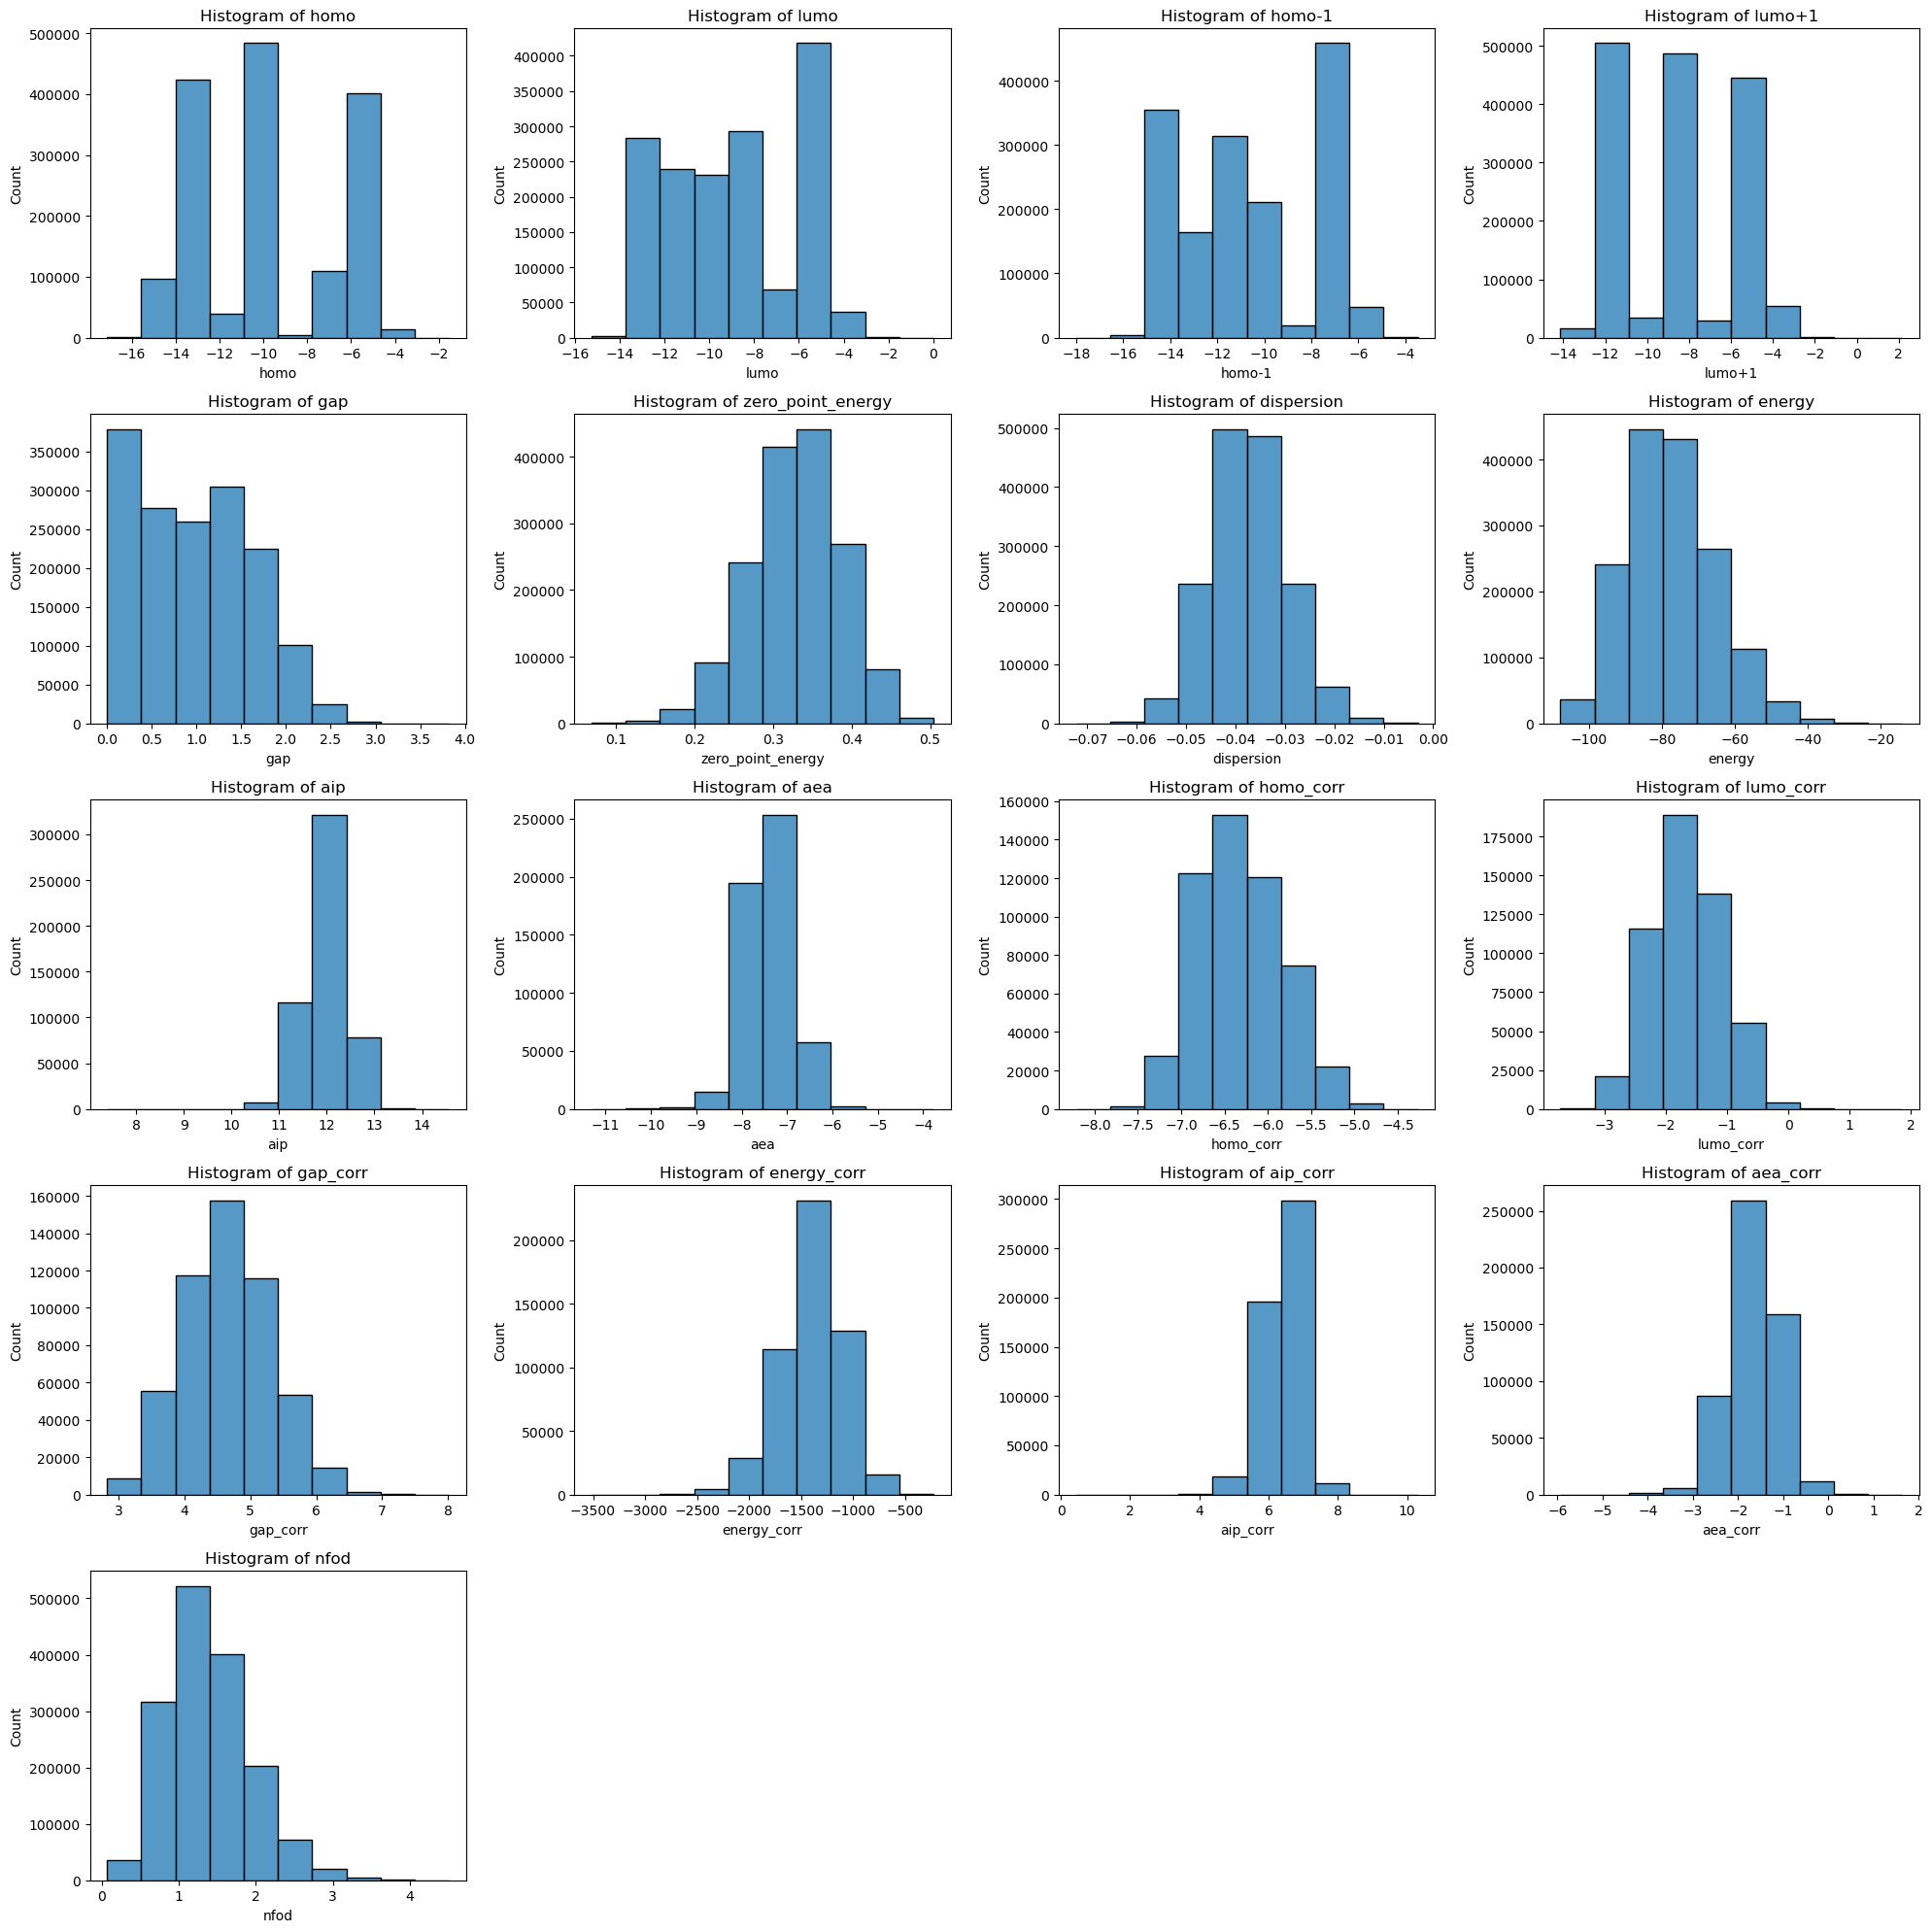

In [38]:
numeric_cols = df.select_dtypes(include=['float64']).columns

# Define subplot grid
n_cols = 4   # number of plots per row
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=10, kde=False, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

w.r.t those whose charge is zero

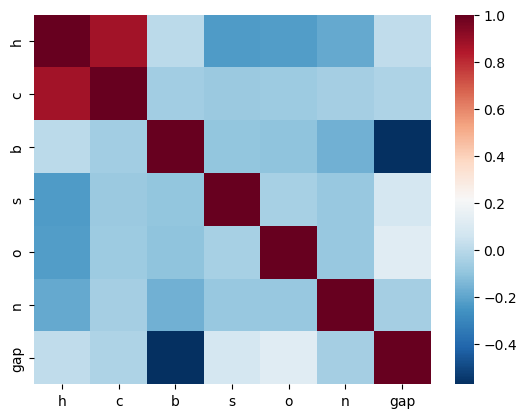

In [69]:
cols = [
    # 'rings','aromatic_rings','atoms','heteroatoms','heterocycles','branch',
    # 'cyclobutadiene','pyrrole','borole','furan','thiophene','dhdiborinine',
    # '14diborinine','pyrazine','pyridine','borinine','benzene',
    'h','c','b','s','o','n',
    # 'homo','lumo','homo-1','lumo+1', 
    'gap',
]

df_charge_0 = df.loc[df['charge'] == 0, cols]
charge_0_corr = df_charge_0.corr()

sns.heatmap(charge_0_corr, annot=False, cmap='RdBu_r')
plt.show()

In [89]:
corr_pairs = charge_0_corr.unstack()
corr_pairs = corr_pairs.drop(labels=[(col, col) for col in charge_0_corr.columns])
corr_df = corr_pairs.reset_index()
corr_df.columns = ["Feature1", "Feature2", "Correlation"]

corr_df[["Feature1", "Feature2"]] = pd.DataFrame(
    np.sort(corr_df[["Feature1", "Feature2"]].values, axis=1),
    index=corr_df.index)
corr_df = corr_df.drop_duplicates(subset=["Feature1", "Feature2"])
high_corr = corr_df[abs(corr_df["Correlation"]) >= 0.2].sort_values(by="Correlation", ascending=False)
high_corr

,Feature1,Feature2,Correlation
0,c,h,0.871978
3,h,o,-0.226380
2,h,s,-0.231395
17,b,gap,-0.570724


Remove energy columns containing NaNs

In [ ]:
cols = [
    # 'rings','aromatic_rings','atoms','heteroatoms','heterocycles','branch',
    # 'cyclobutadiene','pyrrole','borole','furan','thiophene','dhdiborinine',
    # '14diborinine','pyrazine','pyridine','borinine','benzene',
    'h','c','b','s','o','n',
    # 'homo','lumo','homo-1','lumo+1', 
    'zero_point_energy', 'gap',
]

df_dropna = df.loc[df['charge'] == 0, cols]
charge_0_corr = df_charge_0.corr()

sns.heatmap(charge_0_corr, annot=False, cmap='RdBu_r')
plt.show()

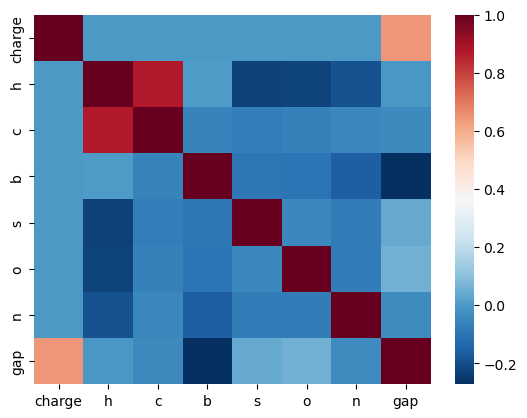

In [92]:
cols_to_drop = [
    'name','formula','inchi','smiles',
    'aip','aea', 'homo_corr','lumo_corr','gap_corr','energy_corr','aip_corr','aea_corr','dipole']
df_new = df.drop(columns=cols_to_drop)

cols = [
    'charge',
    # 'rings','aromatic_rings','atoms','heteroatoms','heterocycles','branch',
    # 'cyclobutadiene','pyrrole','borole','furan','thiophene','dhdiborinine',
    # '14diborinine','pyrazine','pyridine','borinine','benzene',
    'h','c','b','s','o','n',
    # 'homo','lumo','homo-1','lumo+1', 
    'gap',
]

df_new = df_new[cols]
df_new_corr = df_new.corr()

sns.heatmap(df_new_corr, annot=False, cmap='RdBu_r')
plt.show()

In [ ]:
df_new_corr = df_new.corr()
corr_pairs = df_new_corr.unstack()
corr_pairs = corr_pairs.drop(labels=[(col, col) for col in df_new_corr.columns])
corr_df = corr_pairs.reset_index()
corr_df.columns = ["Feature1", "Feature2", "Correlation"]
corr_df[["Feature1", "Feature2"]] = pd.DataFrame(
    np.sort(corr_df[["Feature1", "Feature2"]].values, axis=1),
    index=corr_df.index
)
corr_df = corr_df.drop_duplicates(subset=["Feature1", "Feature2"])
high_corr = corr_df[abs(corr_df["Correlation"]) >= 0.2] \
    .sort_values(by="Correlation", ascending=False)
high_corr

   Feature1 Feature2  Correlation
8         c        h     0.871978
6    charge      gap     0.643302
11        h        o    -0.226380
10        h        s    -0.231395
27        b      gap    -0.272569


Conclusion : Strong correlation between the HOMO-LUMO gap and B count, which matches with theory.